#  Project Title - Seasonal Agriculture Performance Analysis

## Introduction

This project analyzes agricultural performance across different seasons, geographical areas, farming conditions, resource usage, and economic outcomes.

The analysis focuses on identifying seasonal patterns, comparing agricultural performance, and understanding the relationships between environmental conditions, resource usage, crop yield, and profitability.

## Objectives

- Explore and understand the agricultural dataset.
- Clean and prepare the data for analysis.
- Compare agricultural performance across different seasons.
- Analyze relationships between environmental conditions and crop yield.
- Examine resource usage and water efficiency.
- Compare profitability across seasons and irrigation methods.
- Identify important patterns and insights from the data.
- Provide conclusions and recommendations based on the analysis.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_excel ('/content/sample_data/seasonal_agriculture_performance_dataset .xlsx')

In [15]:
df.head()
df.shape
df.columns
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()
df['Season'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


In [16]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [17]:
(df.isnull().sum() / len(df) * 100).round(2)

,0
Farm_ID,0.0
State,0.0
District,0.0
Crop,0.0
Season,0.0
Farm_Area_Hectares,0.0
Rainfall_mm,1.2
Avg_Temperature_C,0.0
Humidity_pct,0.0
Sunlight_Hours_Day,0.0


In [18]:
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(
    df['Rainfall_mm'].median()
)

In [19]:
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(
    df['Soil_Moisture_pct'].median()
)

In [20]:
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(
    df['Yield_Tonnes_Ha'].median()
)

In [21]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,0
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    4000 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              4000 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

(4000, 28)

In [24]:
# Check missing values
df.isnull().sum()

# Fill missing numerical values with median
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].median())

df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(
    df['Soil_Moisture_pct'].median()
)

df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(
    df['Yield_Tonnes_Ha'].median()
)

# Check missing values again
df.isnull().sum()

# Check duplicate rows
df.duplicated().sum()

# Check final dataset shape
df.shape

(4000, 28)

## Question 1: Seasonal Agricultural Performance

### Question:
How does agricultural performance vary across different seasons?

In [25]:
# Seasonal Performance Analysis

season_summary = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Profit_INR': 'mean'
}).reset_index()

season_summary

,Season,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR
0,Kharif,5.628612,46.311192,710719.055649,531804.408094,178914.647555
1,Rabi,5.039435,41.486712,601526.048556,513836.578365,87689.470191
2,Zaid,4.641313,38.886111,519171.904040,543976.728956,-24804.824916


In [26]:
season_summary.round(2)

,Season,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR
0,Kharif,5.63,46.31,710719.06,531804.41,178914.65
1,Rabi,5.04,41.49,601526.05,513836.58,87689.47
2,Zaid,4.64,38.89,519171.90,543976.73,-24804.82


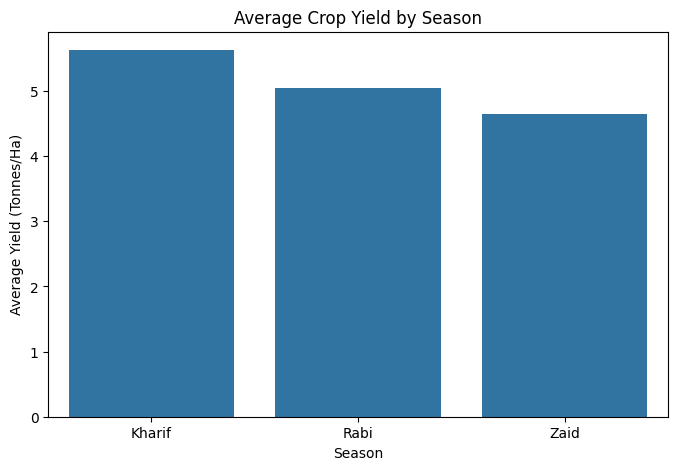

In [27]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=season_summary,
    x='Season',
    y='Yield_Tonnes_Ha'
)

plt.title('Average Crop Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')

plt.show()

In [28]:
season_summary = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Profit_INR': 'mean'
}).reset_index()

In [29]:
season_summary

,Season,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR
0,Kharif,5.628612,46.311192,710719.055649,531804.408094,178914.647555
1,Rabi,5.039435,41.486712,601526.048556,513836.578365,87689.470191
2,Zaid,4.641313,38.886111,519171.904040,543976.728956,-24804.824916


In [30]:
season_summary.round(2)

,Season,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR
0,Kharif,5.63,46.31,710719.06,531804.41,178914.65
1,Rabi,5.04,41.49,601526.05,513836.58,87689.47
2,Zaid,4.64,38.89,519171.90,543976.73,-24804.82


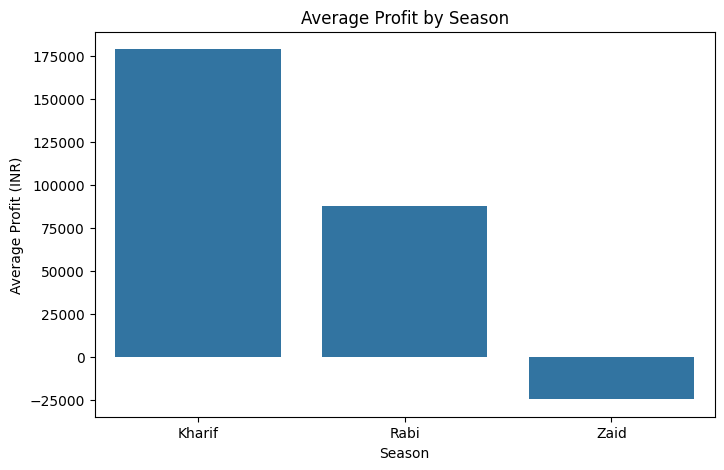

In [31]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=season_summary,
    x='Season',
    y='Profit_INR'
)

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')

plt.show()

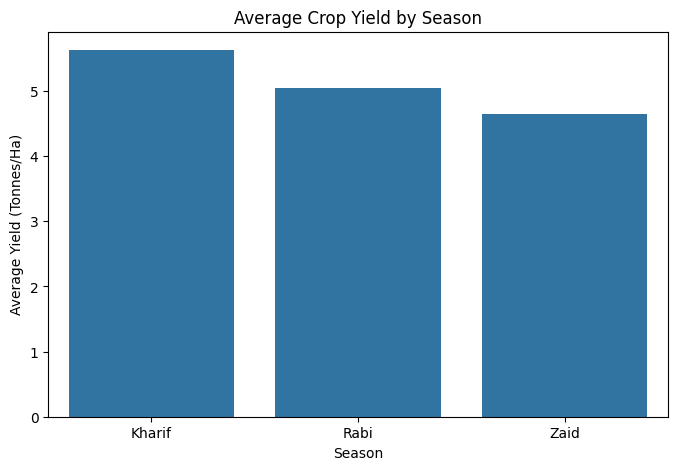

In [32]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=season_summary,
    x='Season',
    y='Yield_Tonnes_Ha'
)

plt.title('Average Crop Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')

plt.show()

In [33]:
season_economics = df.groupby('Season').agg({
    'Revenue_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Profit_INR': 'mean'
}).reset_index()

season_economics.round(2)

,Season,Revenue_INR,Total_Cost_INR,Profit_INR
0,Kharif,710719.06,531804.41,178914.65
1,Rabi,601526.05,513836.58,87689.47
2,Zaid,519171.90,543976.73,-24804.82


In [35]:
season_economics.round(2)

,Season,Revenue_INR,Total_Cost_INR,Profit_INR
0,Kharif,710719.06,531804.41,178914.65
1,Rabi,601526.05,513836.58,87689.47
2,Zaid,519171.90,543976.73,-24804.82


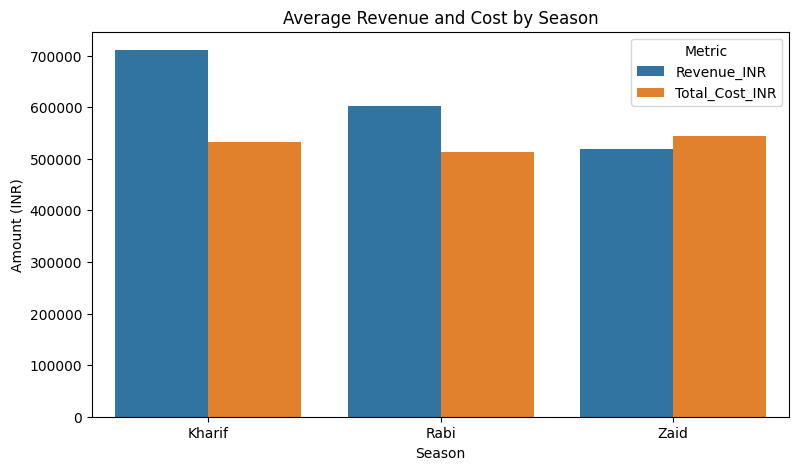

In [36]:
economics_plot = season_economics.melt(
    id_vars='Season',
    value_vars=['Revenue_INR', 'Total_Cost_INR'],
    var_name='Metric',
    value_name='Amount'
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=economics_plot,
    x='Season',
    y='Amount',
    hue='Metric'
)

plt.title('Average Revenue and Cost by Season')
plt.xlabel('Season')
plt.ylabel('Amount (INR)')

plt.show()

In [37]:
season_economics.round(2)

,Season,Revenue_INR,Total_Cost_INR,Profit_INR
0,Kharif,710719.06,531804.41,178914.65
1,Rabi,601526.05,513836.58,87689.47
2,Zaid,519171.90,543976.73,-24804.82


### Interpretation:

Kharif season recorded the highest average crop yield and average profit among the three seasons. Rabi season showed moderate performance, while Zaid season recorded the lowest average yield and a negative average profit.

In terms of economic performance, Kharif generated the highest average revenue and profit. Rabi remained profitable but generated lower returns. In Zaid season, the average total cost was higher than the average revenue, resulting in a negative average profit.

## Question 2: Rainfall and Crop Yield

### Question:
Does rainfall have a relationship with crop yield?

In [39]:
rainfall_yield_corr = df['Rainfall_mm'].corr(
    df['Yield_Tonnes_Ha']
)

rainfall_yield_corr

np.float64(0.030950993551650874)

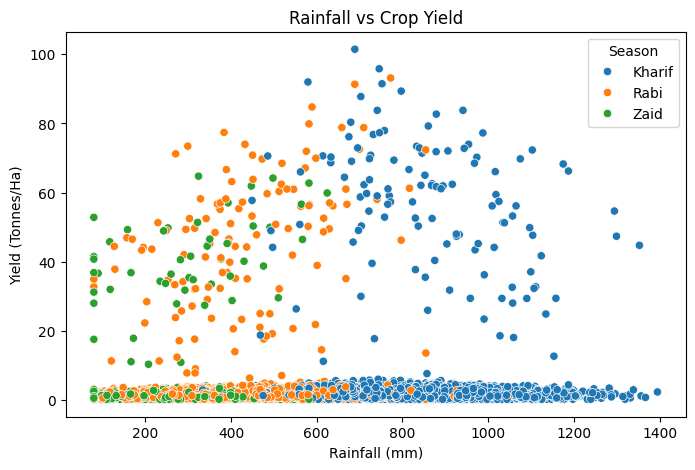

In [40]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Rainfall vs Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

### Interpretation:

The scatter plot shows a very weak relationship between rainfall and crop yield. The correlation coefficient is approximately 0.031, which indicates a very weak positive linear relationship.

Therefore, rainfall alone does not strongly explain variations in crop yield in this dataset.

## Question 3: Temperature and Crop Yield

### Question:
Does average temperature have a relationship with crop yield?

In [41]:
temperature_yield_corr = df['Avg_Temperature_C'].corr(
    df['Yield_Tonnes_Ha']
)

temperature_yield_corr

np.float64(0.009996320546703593)

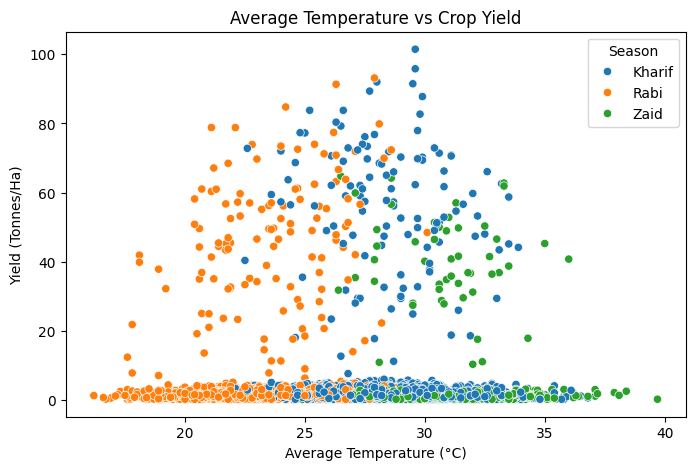

In [42]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Avg_Temperature_C',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Average Temperature vs Crop Yield')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

### Interpretation:

The scatter plot shows no clear relationship between average temperature and crop yield. The correlation coefficient is approximately 0.01, which indicates an extremely weak positive linear relationship.

Therefore, average temperature alone does not strongly explain variations in crop yield in this dataset. The yield values vary considerably across different temperature levels and seasons.

## Question 4: Resource Usage Across Seasons

### Question:
How does resource usage vary across different seasons?

In [43]:
resource_summary = df.groupby('Season').agg({
    'Fertilizer_kg_ha': 'mean',
    'Water_Used_m3': 'mean'
}).reset_index()

resource_summary.round(2)

,Season,Fertilizer_kg_ha,Water_Used_m3
0,Kharif,187.08,6102.20
1,Rabi,185.41,5846.99
2,Zaid,184.64,6419.89


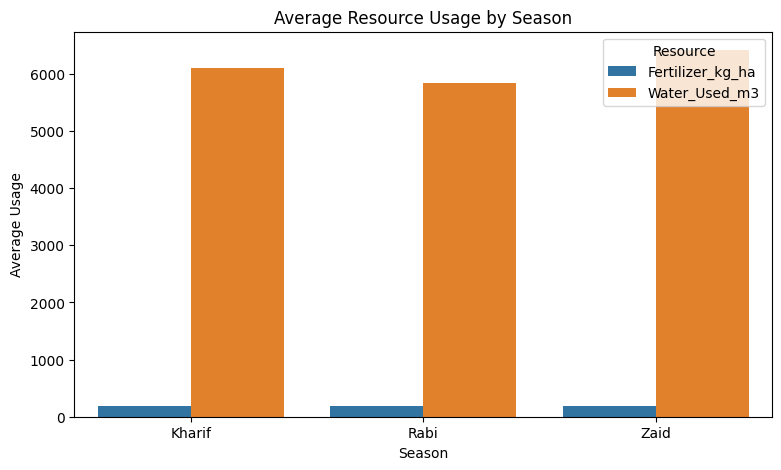

In [44]:
plt.figure(figsize=(9, 5))

resource_plot = resource_summary.melt(
    id_vars='Season',
    value_vars=['Fertilizer_kg_ha', 'Water_Used_m3'],
    var_name='Resource',
    value_name='Average Usage'
)

sns.barplot(
    data=resource_plot,
    x='Season',
    y='Average Usage',
    hue='Resource'
)

plt.title('Average Resource Usage by Season')
plt.xlabel('Season')
plt.ylabel('Average Usage')
plt.show()

### Interpretation:

Resource usage varies across the three seasons. Kharif has the highest average fertilizer usage at 187.08 kg/ha, while Zaid has the lowest at 184.64 kg/ha.

For water usage, Zaid has the highest average water consumption at 6419.89 m³, followed by Kharif at 6102.20 m³. Rabi has the lowest average water usage at 5846.99 m³.

Overall, fertilizer usage is relatively similar across seasons, while water usage shows more noticeable seasonal variation.

## Question 5: Soil Moisture and Crop Yield

### Question:
Does soil moisture have a relationship with crop yield?

In [45]:
soil_moisture_yield_corr = df['Soil_Moisture_pct'].corr(
    df['Yield_Tonnes_Ha']
)

soil_moisture_yield_corr

np.float64(0.010999346063015853)

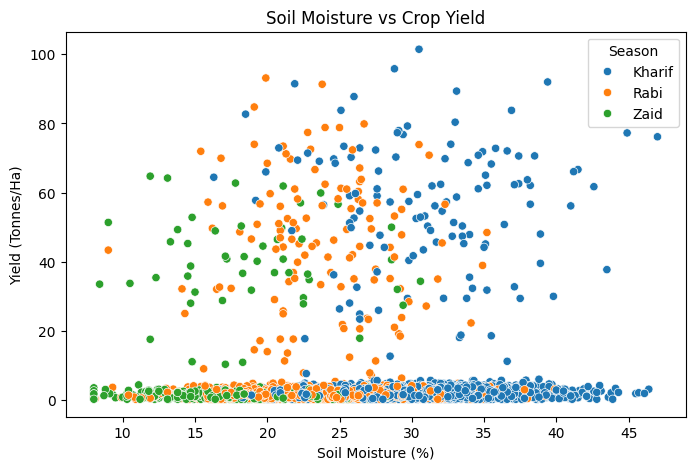

In [46]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Soil_Moisture_pct',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Soil Moisture vs Crop Yield')
plt.xlabel('Soil Moisture (%)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

### Interpretation:

The scatter plot shows no clear relationship between soil moisture and crop yield. The correlation coefficient is approximately 0.011, which indicates an extremely weak positive linear relationship.

Therefore, soil moisture alone does not strongly explain variations in crop yield in this dataset.

## Question 6: Market Price and Profit

### Question:
Does market price have a relationship with farm profit?

In [47]:
price_profit_corr = df['Market_Price_INR_Tonne'].corr(
    df['Profit_INR']
)

price_profit_corr

np.float64(0.22511939019981)

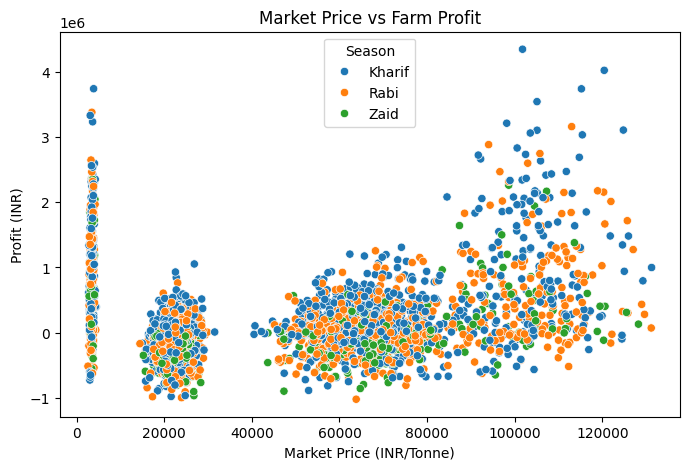

In [48]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Market_Price_INR_Tonne',
    y='Profit_INR',
    hue='Season'
)

plt.title('Market Price vs Farm Profit')
plt.xlabel('Market Price (INR/Tonne)')
plt.ylabel('Profit (INR)')
plt.show()

### Interpretation:

The scatter plot shows a weak positive relationship between market price and farm profit. The correlation coefficient is approximately 0.225, indicating that higher market prices are somewhat associated with higher profits.

However, the relationship is not strong, which suggests that factors other than market price also influence farm profit.

## Question 7: Water Efficiency Across Seasons

### Question:
Which season has the highest average water efficiency?

In [49]:
water_efficiency_summary = df.groupby('Season')[
    'Water_Efficiency_t_per_1000m3'
].mean().reset_index()

water_efficiency_summary.round(2)

,Season,Water_Efficiency_t_per_1000m3
0,Kharif,5.89
1,Rabi,5.19
2,Zaid,4.41


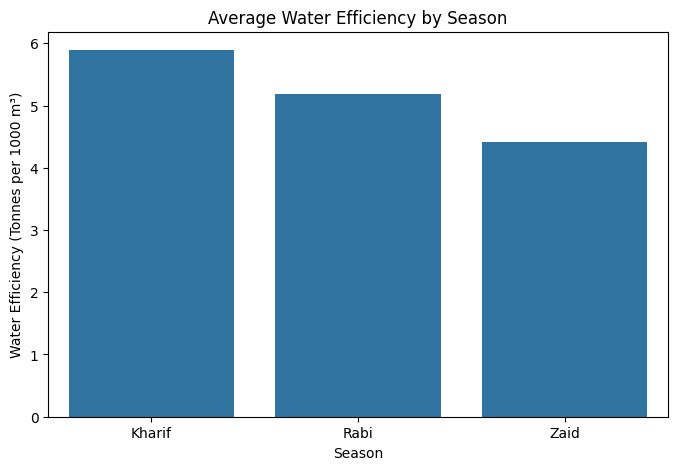

In [50]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=water_efficiency_summary,
    x='Season',
    y='Water_Efficiency_t_per_1000m3'
)

plt.title('Average Water Efficiency by Season')
plt.xlabel('Season')
plt.ylabel('Water Efficiency (Tonnes per 1000 m³)')
plt.show()

### Interpretation:

Kharif season has the highest average water efficiency at 5.89 tonnes per 1000 m³. Rabi has a moderate water efficiency of 5.19 tonnes per 1000 m³, while Zaid has the lowest water efficiency at 4.41 tonnes per 1000 m³.

This indicates that Kharif produces more crop yield per unit of water used compared with Rabi and Zaid seasons.

## Question 8: Disease/Pest Risk and Crop Yield

### Question:
Does disease and pest risk have a relationship with crop yield?

In [51]:
disease_yield_corr = df['Disease_Pest_Risk_pct'].corr(
    df['Yield_Tonnes_Ha']
)

disease_yield_corr

np.float64(0.014291575329120754)

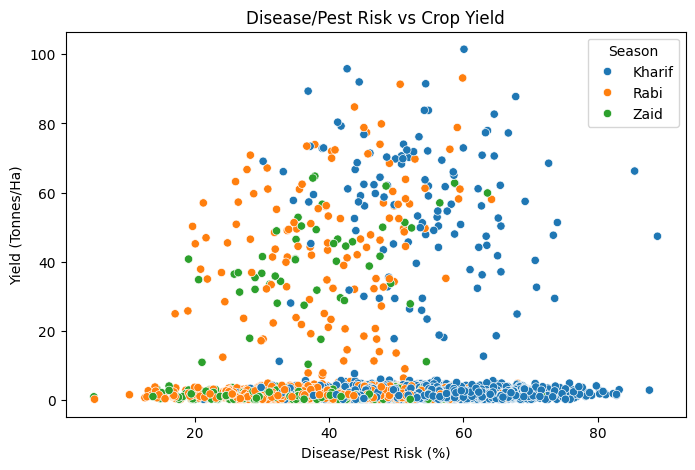

In [52]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Disease_Pest_Risk_pct',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Disease/Pest Risk vs Crop Yield')
plt.xlabel('Disease/Pest Risk (%)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

### Interpretation:

The scatter plot shows no clear relationship between disease and pest risk and crop yield. The correlation coefficient is approximately 0.014, which indicates an extremely weak positive linear relationship.

Therefore, disease and pest risk alone does not strongly explain variations in crop yield in this dataset.

## Question 9: Seed Quality and Crop Yield

### Question:
Does seed quality have a relationship with crop yield?

In [53]:
seed_quality_yield_corr = df['Seed_Quality_Score'].corr(
    df['Yield_Tonnes_Ha']
)

seed_quality_yield_corr

np.float64(-0.007208500583094007)

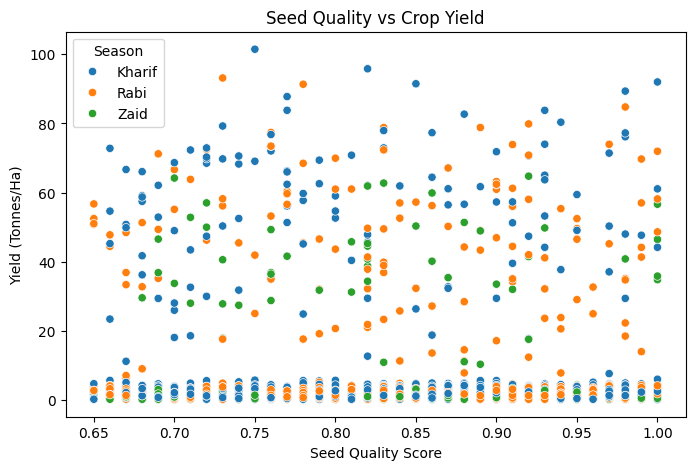

In [54]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Seed_Quality_Score',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Seed Quality vs Crop Yield')
plt.xlabel('Seed Quality Score')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

### Interpretation:

The scatter plot shows no clear relationship between seed quality and crop yield. The correlation coefficient is approximately -0.007, which indicates an extremely weak negative linear relationship.

Therefore, seed quality score alone does not strongly explain variations in crop yield in this dataset.

## Question 10: Irrigation Method and Crop Yield

### Question:
How does average crop yield vary across different irrigation methods?

In [55]:
irrigation_yield_summary = df.groupby('Irrigation_Method')[
    'Yield_Tonnes_Ha'
].mean().reset_index()

irrigation_yield_summary.round(2)

,Irrigation_Method,Yield_Tonnes_Ha
0,Drip,6.58
1,Flood,4.86
2,Rainfed,4.60
3,Sprinkler,5.16


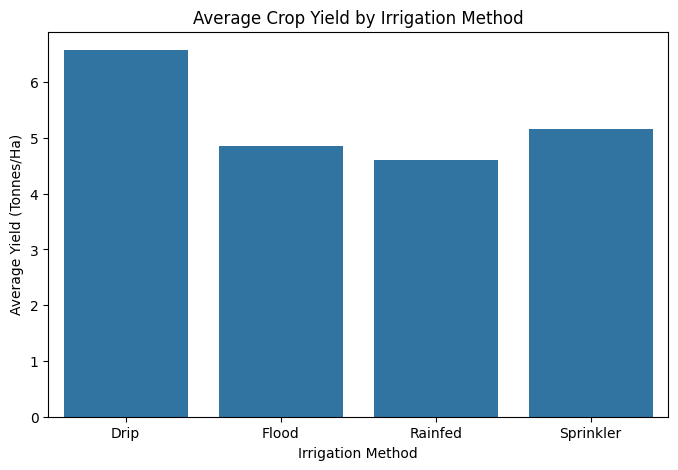

In [56]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=irrigation_yield_summary,
    x='Irrigation_Method',
    y='Yield_Tonnes_Ha'
)

plt.title('Average Crop Yield by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.show()

### Interpretation:

The average crop yield varies across different irrigation methods. Drip irrigation has the highest average yield at 6.58 tonnes/ha, followed by Sprinkler irrigation at 5.16 tonnes/ha.

Flood irrigation has an average yield of 4.86 tonnes/ha, while Rainfed farming has the lowest average yield at 4.60 tonnes/ha.

Overall, farms using Drip irrigation show the highest average crop yield in this dataset, while Rainfed farming shows the lowest.

## Question 11: Farm Area and Production

### Question:
Does farm area have a relationship with total crop production?

In [57]:
farm_area_production_corr = df['Farm_Area_Hectares'].corr(
    df['Production_Tonnes']
)

farm_area_production_corr

np.float64(0.197841674306544)

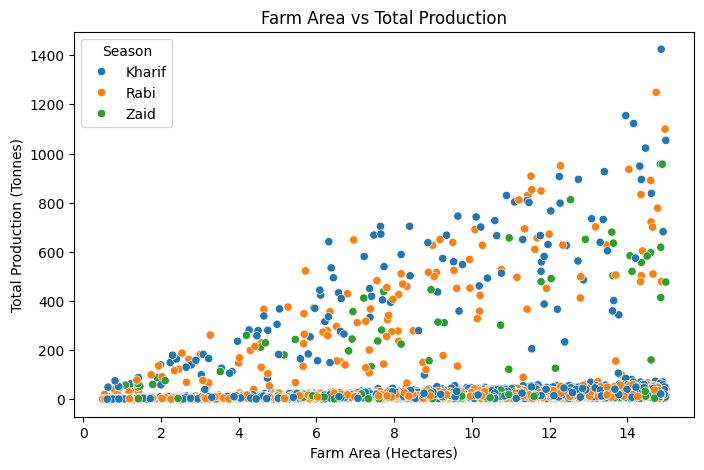

In [58]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Farm_Area_Hectares',
    y='Production_Tonnes',
    hue='Season'
)

plt.title('Farm Area vs Total Production')
plt.xlabel('Farm Area (Hectares)')
plt.ylabel('Total Production (Tonnes)')
plt.show()

### Interpretation:

The scatter plot shows a weak positive relationship between farm area and total crop production. The correlation coefficient is approximately 0.198, indicating that larger farm areas are somewhat associated with higher total production.

However, the relationship is not strong, suggesting that factors other than farm area also influence total crop production.

## Question 12: Fertilizer Usage and Crop Yield

### Question:
Does fertilizer usage have a relationship with crop yield?

In [59]:
fertilizer_yield_corr = df['Fertilizer_kg_ha'].corr(
    df['Yield_Tonnes_Ha']
)

fertilizer_yield_corr

np.float64(1.7712703696042472e-05)

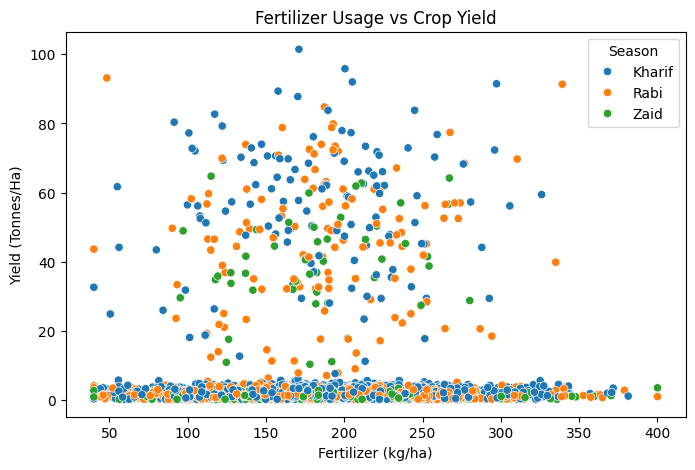

In [60]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Fertilizer_kg_ha',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Fertilizer Usage vs Crop Yield')
plt.xlabel('Fertilizer (kg/ha)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

### Interpretation:

The scatter plot shows no clear relationship between fertilizer usage and crop yield. The correlation coefficient is approximately 0.00, indicating almost no linear relationship between the two variables.

Therefore, fertilizer usage alone does not strongly explain variations in crop yield in this dataset.

## Question 13: Profitability Across Irrigation Methods

### Question:
How does average farm profit vary across different irrigation methods?

In [61]:
irrigation_profit_summary = df.groupby('Irrigation_Method')[
    'Profit_INR'
].mean().reset_index()

irrigation_profit_summary.round(2)

,Irrigation_Method,Profit_INR
0,Drip,219626.00
1,Flood,73354.02
2,Rainfed,79050.37
3,Sprinkler,91121.08


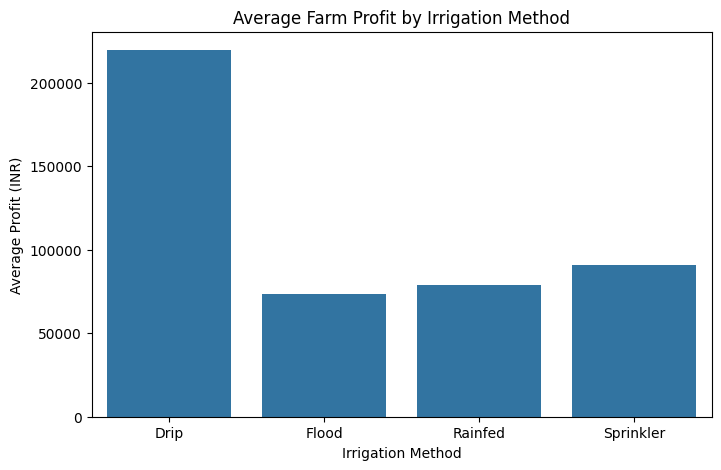

In [62]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=irrigation_profit_summary,
    x='Irrigation_Method',
    y='Profit_INR'
)

plt.title('Average Farm Profit by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Average Profit (INR)')
plt.show()

### Interpretation:

The average farm profit varies considerably across irrigation methods. Drip irrigation has the highest average profit at ₹219,626, followed by Sprinkler irrigation at ₹91,121.08.

Rainfed farming has an average profit of ₹79,050.37, while Flood irrigation has the lowest average profit at ₹73,354.02.

Overall, farms using Drip irrigation show the highest average profitability in this dataset.

## Overall Findings

The analysis of seasonal agricultural performance reveals several important patterns across seasons, environmental conditions, resource usage, and economic performance.

### Key Findings

- Kharif season showed the highest average crop yield and average profit.
- Zaid season showed the lowest average yield and negative average profit.
- Rainfall showed a very weak relationship with crop yield.
- Average temperature showed an extremely weak relationship with crop yield.
- Kharif had the highest average water efficiency.
- Drip irrigation showed the highest average crop yield and average farm profit.

## Conclusion

The analysis shows that agricultural performance varies across seasons, environmental conditions, resource usage, and irrigation methods. Kharif season showed the strongest overall performance, while Zaid season showed comparatively lower profitability.

The analysis also shows that some individual factors, such as rainfall, temperature, seed quality, fertilizer usage, and disease/pest risk, had very weak relationships with crop yield. Drip irrigation showed the highest average yield and profitability among the irrigation methods analyzed.

Overall, the findings can help farmers and agricultural planners understand seasonal performance and make better decisions regarding irrigation, resource usage, and farm planning.

## Recommendations

- Farmers can consider suitable irrigation methods based on crop and seasonal conditions.
- Drip irrigation may be considered where feasible because it showed higher average yield and profitability in this dataset.
- Farmers should monitor costs carefully, especially during seasons with lower profitability such as Zaid.
- Seasonal planning can help farmers allocate water and other resources more effectively.
- Agricultural decisions should consider multiple factors together rather than relying on a single environmental factor.

## Final Summary

This project analyzed agricultural performance across different seasons, environmental conditions, resource usage, and irrigation methods.

The analysis found that Kharif season performed better in terms of average yield, profit, and water efficiency, while Zaid showed comparatively weaker economic performance. Drip irrigation showed the highest average yield and profitability among the irrigation methods.

Overall, the analysis provides useful insights into seasonal agricultural performance and can support better planning of irrigation, resources, and farming activities.